# Exercise 2: Finetuning BERT for Binary Text Classification

Pipeline:
1. Load dataset (IMDb)
2. Explore + create splits → save JSON
3. Tokenize
4. Define TrainingArguments + Trainer
5. Train + monitor
6. Save history & best model
7. Evaluate + Confusion Matrix
8. Error Analysis

In [1]:
import sys, os, json
sys.path.append('..')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch

from datasets import load_dataset
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer
)
import evaluate
from sklearn.metrics import confusion_matrix, classification_report

print(f'CUDA available: {torch.cuda.is_available()}')
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Using device: {device}')

I0000 00:00:1787108155.128928  373013 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1787108155.178165  373013 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
/home/dangkien/.local/lib/python3.10/site-packages/google/api_core/_python_version_support.py:273: FutureWarning: You are using a Python version (3.10.12) which Google will stop supporting in new releases of google.api_core once it reaches its end of life (2026-10-04). Please upgrade to the latest Python version, or at least Python 3.11, to continue receiving updates for google.api_core past that date.
  warning

CUDA available: True
Using device: cuda


## 1. Load Dataset

In [2]:
dataset = load_dataset('imdb')
print(dataset)
print(f'\nTrain samples: {len(dataset["train"])}')
print(f'Test samples:  {len(dataset["test"])}')
print(f'Features: {dataset["train"].features}')

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 25000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 25000
    })
    unsupervised: Dataset({
        features: ['text', 'label'],
        num_rows: 50000
    })
})

Train samples: 25000
Test samples:  25000
Features: {'text': Value('string'), 'label': ClassLabel(names=['neg', 'pos'])}


## 2. Data Exploration

In [3]:
train_data = dataset['train']
labels = train_data['label']

# Class distribution
from collections import Counter
dist = Counter(labels)
print('Class distribution (train):')
for label, count in sorted(dist.items()):
    name = 'NEGATIVE' if label == 0 else 'POSITIVE'
    print(f'  {label} ({name}): {count} ({count/len(labels)*100:.1f}%)')

# Text length
lengths = [len(t.split()) for t in train_data['text']]
print(f'\nText length (words):')
print(f'  Mean:   {np.mean(lengths):.0f}')
print(f'  Median: {np.median(lengths):.0f}')
print(f'  Max:    {np.max(lengths)}')
print(f'  Min:    {np.min(lengths)}')

Class distribution (train):
  0 (NEGATIVE): 12500 (50.0%)
  1 (POSITIVE): 12500 (50.0%)

Text length (words):
  Mean:   234
  Median: 174
  Max:    2470
  Min:    10


In [4]:
# Show examples
import random
random.seed(42)
for label_id, label_name in [(0, 'NEGATIVE'), (1, 'POSITIVE')]:
    idxs = [i for i, l in enumerate(labels) if l == label_id]
    sample = random.choice(idxs)
    text = train_data[sample]['text']
    print(f'--- {label_name} example ---')
    print(text[:300] + '...')
    print()

--- NEGATIVE example ---
Giant crabs cursing in Japanese? What was in that drink? A terrible movie, but laughable. I love the invisible Samurai ghosties running around. Drink much beer before you see this movie....

--- POSITIVE example ---
Arthur is middle aged rich 'kid' who drinks like a fish. Arthur does what he feels like and says whatever comes into his mind. He likes to boast about his riches and knows that he is a spoiled brat. He spends money on people he don't know and finds everything funny. Arthur must marry a high class gi...



## 3. Create & Save Splits

**QUAN TRỌNG**: Tạo splits 1 lần duy nhất, lưu JSON để tái sử dụng.

In [5]:
SPLITS_DIR = '../splits'
os.makedirs(SPLITS_DIR, exist_ok=True)

SPLITS_EXIST = all([
    os.path.exists(f'{SPLITS_DIR}/train_indices.json'),
    os.path.exists(f'{SPLITS_DIR}/val_indices.json'),
    os.path.exists(f'{SPLITS_DIR}/test_indices.json'),
])

if not SPLITS_EXIST:
    from sklearn.model_selection import train_test_split

    # Dùng toàn bộ IMDb train set (25000 samples)
    all_idx = list(range(len(train_data)))
    all_labels = train_data['label']

    # 70% train, 15% val, 15% test (stratified)
    train_idx, temp_idx = train_test_split(
        all_idx, test_size=0.30, random_state=42, stratify=all_labels
    )
    temp_labels = [all_labels[i] for i in temp_idx]
    val_idx, test_idx = train_test_split(
        temp_idx, test_size=0.50, random_state=42, stratify=temp_labels
    )

    for name, idx in [('train', train_idx), ('val', val_idx), ('test', test_idx)]:
        with open(f'{SPLITS_DIR}/{name}_indices.json', 'w') as f:
            json.dump(idx, f)
    print('Created and saved new splits')
else:
    print('Loading existing splits (reproducibility preserved)')

# Load splits
with open(f'{SPLITS_DIR}/train_indices.json') as f: train_idx = json.load(f)
with open(f'{SPLITS_DIR}/val_indices.json')   as f: val_idx   = json.load(f)
with open(f'{SPLITS_DIR}/test_indices.json')  as f: test_idx  = json.load(f)

print(f'Train: {len(train_idx)} | Val: {len(val_idx)} | Test: {len(test_idx)}')

Loading existing splits (reproducibility preserved)
Train: 17500 | Val: 3750 | Test: 3750


## 4. Load Model & Tokenizer

In [6]:
MODEL_NAME = 'distilbert-base-uncased'
NUM_LABELS = 2

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
model = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=NUM_LABELS)

total_params = sum(p.numel() for p in model.parameters())
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Model: {MODEL_NAME}')
print(f'Total parameters:    {total_params:,}')
print(f'Trainable parameters: {trainable:,}')

Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Model: distilbert-base-uncased
Total parameters:    66,955,010
Trainable parameters: 66,955,010


## 5. Tokenize Dataset

In [7]:
MAX_LENGTH = 256  # Giảm từ 512 để train nhanh hơn

def tokenize_fn(examples):
    return tokenizer(
        examples['text'],
        truncation=True,
        padding='max_length',
        max_length=MAX_LENGTH
    )

# Tạo splits từ dataset
train_ds = train_data.select(train_idx)
val_ds   = train_data.select(val_idx)
test_ds  = train_data.select(test_idx)

# Tokenize
train_tok = train_ds.map(tokenize_fn, batched=True, batch_size=500)
val_tok   = val_ds.map(tokenize_fn, batched=True, batch_size=500)
test_tok  = test_ds.map(tokenize_fn, batched=True, batch_size=500)

# Rename label column
train_tok = train_tok.rename_column('label', 'labels')
val_tok   = val_tok.rename_column('label', 'labels')
test_tok  = test_tok.rename_column('label', 'labels')

# Set format for PyTorch
cols = ['input_ids', 'attention_mask', 'labels']
train_tok.set_format('torch', columns=cols)
val_tok.set_format('torch', columns=cols)
test_tok.set_format('torch', columns=cols)

print(f'Train tokenized: {len(train_tok)} samples')
print(f'Val tokenized:   {len(val_tok)} samples')
print(f'Test tokenized:  {len(test_tok)} samples')

Train tokenized: 17500 samples
Val tokenized:   3750 samples
Test tokenized:  3750 samples


## 6. Define Metrics & Training Arguments

In [8]:
acc_metric = evaluate.load('accuracy')
f1_metric  = evaluate.load('f1')

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    acc = acc_metric.compute(predictions=preds, references=labels)['accuracy']
    f1  = f1_metric.compute(predictions=preds, references=labels, average='binary')['f1']
    return {'accuracy': acc, 'f1': f1}

In [9]:
OUTPUT_DIR = '../outputs/exercise2'
os.makedirs(OUTPUT_DIR, exist_ok=True)

training_args = TrainingArguments(
    output_dir=OUTPUT_DIR,
    num_train_epochs=3,
    per_device_train_batch_size=32,
    per_device_eval_batch_size=64,
    learning_rate=2e-5,
    weight_decay=0.01,
    warmup_ratio=0.1,
    eval_strategy='epoch',
    save_strategy='epoch',
    load_best_model_at_end=True,
    metric_for_best_model='accuracy',
    save_total_limit=2,
    logging_steps=50,
    report_to='none',
    fp16=torch.cuda.is_available(),
)

# Save config
config = {
    'model_name': MODEL_NAME,
    'dataset': 'imdb',
    'max_length': MAX_LENGTH,
    'num_train_epochs': 3,
    'batch_size': 32,
    'learning_rate': 2e-5,
    'weight_decay': 0.01,
    'warmup_ratio': 0.1,
    'splits': {'train': len(train_idx), 'val': len(val_idx), 'test': len(test_idx)}
}
with open(f'{OUTPUT_DIR}/config.json', 'w') as f:
    json.dump(config, f, indent=2)
print('Config saved. Training arguments ready.')
print(f'fp16 (mixed precision): {training_args.fp16}')

Config saved. Training arguments ready.
fp16 (mixed precision): True


## 7. Train Model

Cô muốn thấy được quá trình monitor → training progress được in ra mỗi epoch.

In [10]:
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_tok,
    eval_dataset=val_tok,
    compute_metrics=compute_metrics,
    tokenizer=tokenizer,
)

print('Starting training...')
train_result = trainer.train()
print('\nTraining complete!')
print(f'Total training time: {train_result.metrics["train_runtime"]:.0f}s')
print(f'Samples/sec: {train_result.metrics["train_samples_per_second"]:.1f}')

Starting training...

Training complete!
Total training time: 387s
Samples/sec: 135.6


## 8. Save Training History (raw metrics - bắt buộc)

In [11]:
os.makedirs(f'{OUTPUT_DIR}/metrics', exist_ok=True)
os.makedirs(f'{OUTPUT_DIR}/plots', exist_ok=True)
os.makedirs(f'{OUTPUT_DIR}/model', exist_ok=True)

# Save raw history
history = trainer.state.log_history
with open(f'{OUTPUT_DIR}/metrics/training_history.json', 'w') as f:
    json.dump(history, f, indent=2)

df_history = pd.DataFrame(history)
df_history.to_csv(f'{OUTPUT_DIR}/metrics/training_history.csv', index=False)

# Extract epoch-level metrics
eval_logs = [log for log in history if 'eval_loss' in log]
train_logs = [log for log in history if 'loss' in log and 'eval_loss' not in log]

print('Training history saved!')
print(f'Total log entries: {len(history)}')
print(f'Eval checkpoints: {len(eval_logs)}')
print()

print(f'{"Epoch":<8} {"Train Loss":<14} {"Val Loss":<12} {"Val Acc":<12} {"Val F1"}')
print('-' * 60)
for log in eval_logs:
    print(f'{log.get("epoch", "-"):<8.1f} {"-":<14} {log.get("eval_loss", 0):<12.4f} {log.get("eval_accuracy", 0):<12.4f} {log.get("eval_f1", 0):.4f}')

Training history saved!
Total log entries: 35
Eval checkpoints: 3

Epoch    Train Loss     Val Loss     Val Acc      Val F1
------------------------------------------------------------
1.0      -              0.2309       0.9104       0.9091
2.0      -              0.2338       0.9109       0.9110
3.0      -              0.2754       0.9157       0.9163


## 9. Plot Training Curves (Loss + Accuracy per Epoch)

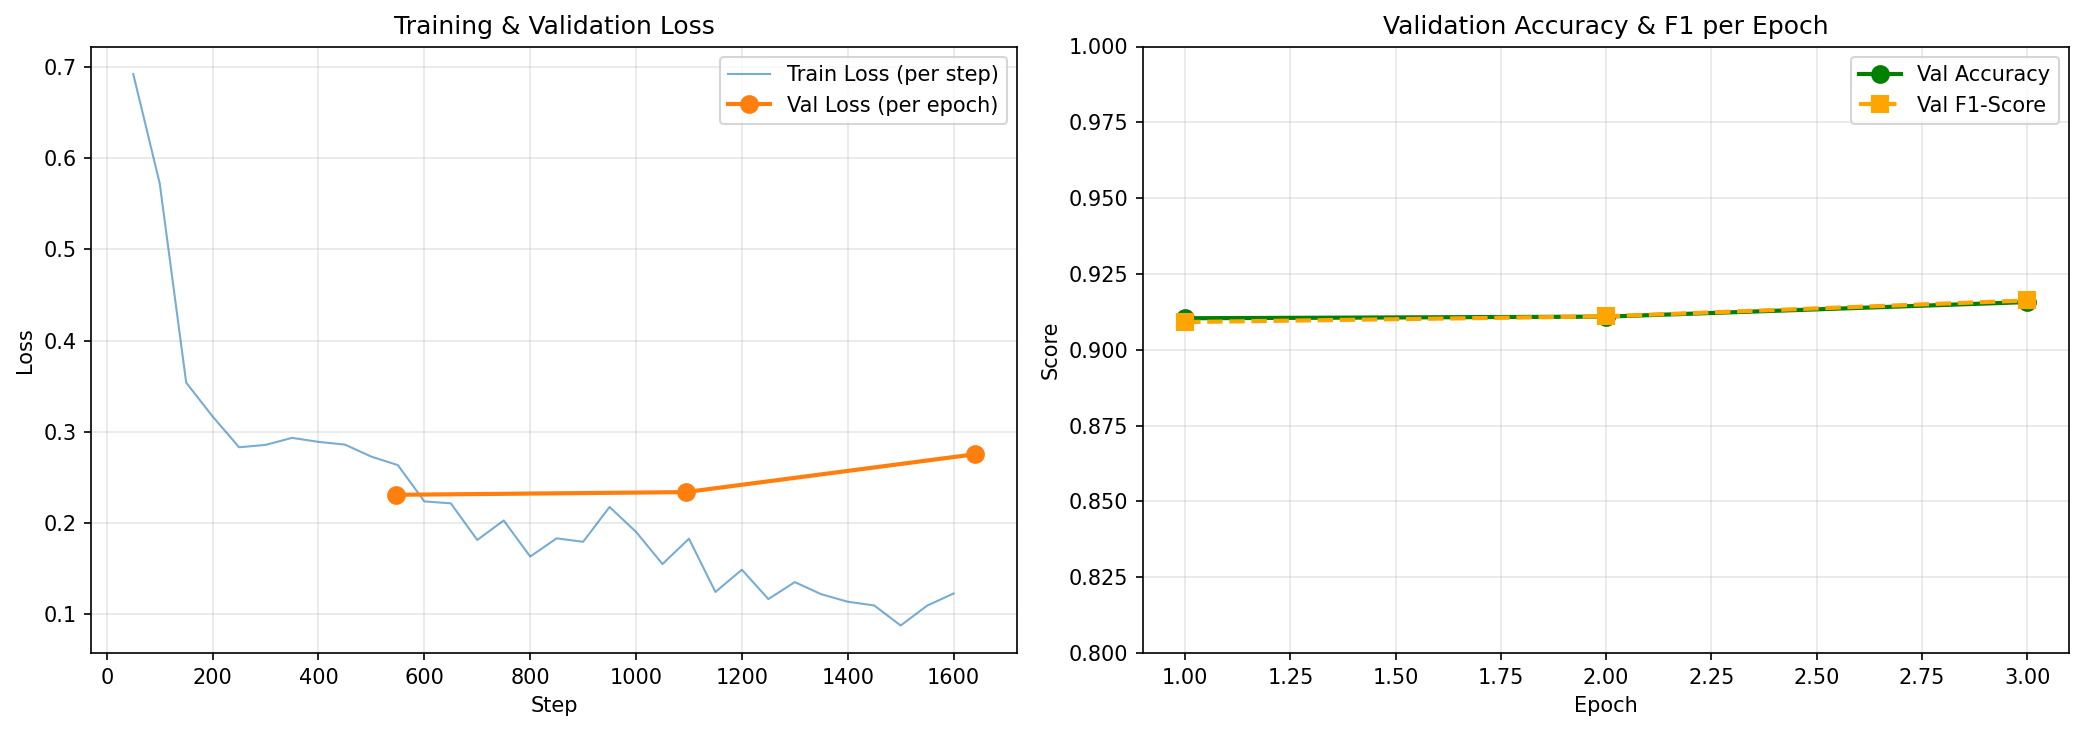

Training curves saved.


In [12]:
epochs = [log['epoch'] for log in eval_logs]
val_losses = [log['eval_loss'] for log in eval_logs]
val_accs = [log['eval_accuracy'] for log in eval_logs]
val_f1s = [log.get('eval_f1', 0) for log in eval_logs]

# Train loss (per step, not epoch)
train_steps = [log['step'] for log in train_logs if 'loss' in log]
train_losses = [log['loss'] for log in train_logs if 'loss' in log]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss
axes[0].plot(train_steps, train_losses, alpha=0.6, label='Train Loss (per step)', linewidth=1)
axes[0].plot([log['step'] for log in eval_logs], val_losses, 'o-', label='Val Loss (per epoch)', linewidth=2, markersize=8)
axes[0].set_xlabel('Step')
axes[0].set_ylabel('Loss')
axes[0].set_title('Training & Validation Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Accuracy + F1
axes[1].plot(epochs, val_accs, 'o-', label='Val Accuracy', linewidth=2, markersize=8, color='green')
axes[1].plot(epochs, val_f1s, 's--', label='Val F1-Score', linewidth=2, markersize=8, color='orange')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Score')
axes[1].set_title('Validation Accuracy & F1 per Epoch')
axes[1].legend()
axes[1].grid(True, alpha=0.3)
axes[1].set_ylim([0.8, 1.0])

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/plots/training_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print('Training curves saved.')

## 10. Save Best Model

In [13]:
trainer.save_model(f'{OUTPUT_DIR}/model/best_model')
tokenizer.save_pretrained(f'{OUTPUT_DIR}/model/best_model')
print(f'Best model saved to {OUTPUT_DIR}/model/best_model')
print(f'Best val accuracy: {trainer.state.best_metric:.4f}')

Best model saved to ../outputs/exercise2/model/best_model
Best val accuracy: 0.9157


## 11. Evaluate on Test Set

In [14]:
test_results = trainer.evaluate(test_tok)

print('Test Set Results:')
print(f'  Loss:     {test_results["eval_loss"]:.4f}')
print(f'  Accuracy: {test_results["eval_accuracy"]:.4f} ({test_results["eval_accuracy"]*100:.2f}%)')
print(f'  F1:       {test_results["eval_f1"]:.4f}')

with open(f'{OUTPUT_DIR}/metrics/test_metrics.json', 'w') as f:
    json.dump(test_results, f, indent=2)
print('Test metrics saved.')

Test Set Results:
  Loss:     0.2719
  Accuracy: 0.9147 (91.47%)
  F1:       0.9146
Test metrics saved.


## 12. Confusion Matrix

### Cấu trúc Confusion Matrix:
- **Hàng (Rows)**: True labels - nhãn THỰC TẾ
- **Cột (Columns)**: Predicted labels - nhãn MÔ HÌNH DỰ ĐOÁN
- **Cell [i,j]**: Số mẫu có nhãn thực tế là i, nhưng model dự đoán là j
- **Đường chéo (Diagonal)**: Dự đoán đúng ✓
- **Ngoài đường chéo**: Dự đoán sai ✗

In [15]:
# Get predictions
preds_output = trainer.predict(test_tok)
y_pred = np.argmax(preds_output.predictions, axis=-1)
y_true = preds_output.label_ids
y_probs = torch.softmax(torch.tensor(preds_output.predictions), dim=-1).numpy()

# Save predictions
pred_df = pd.DataFrame({'true_label': y_true, 'pred_label': y_pred, 'confidence': y_probs.max(axis=1)})
pred_df.to_csv(f'{OUTPUT_DIR}/metrics/predictions.csv', index=False)

CLASS_NAMES = ['NEGATIVE', 'POSITIVE']
cm = confusion_matrix(y_true, y_pred)
np.save(f'{OUTPUT_DIR}/metrics/confusion_matrix.npy', cm)

print('Confusion Matrix:')
print(f'              Predicted')
print(f'              NEG    POS')
print(f'True  NEG  [{cm[0,0]:5d}  {cm[0,1]:5d}]')
print(f'      POS  [{cm[1,0]:5d}  {cm[1,1]:5d}]')
print()
tn, fp, fn, tp = cm.ravel()
print(f'TN (đúng NEG): {tn} | FP (sai - đoán POS nhưng thực là NEG): {fp}')
print(f'FN (sai - đoán NEG nhưng thực là POS): {fn} | TP (đúng POS): {tp}')

Confusion Matrix:
              Predicted
              NEG    POS
True  NEG  [ 1716    159]
      POS  [  161   1714]

TN (đúng NEG): 1716 | FP (sai - đoán POS nhưng thực là NEG): 159
FN (sai - đoán NEG nhưng thực là POS): 161 | TP (đúng POS): 1714


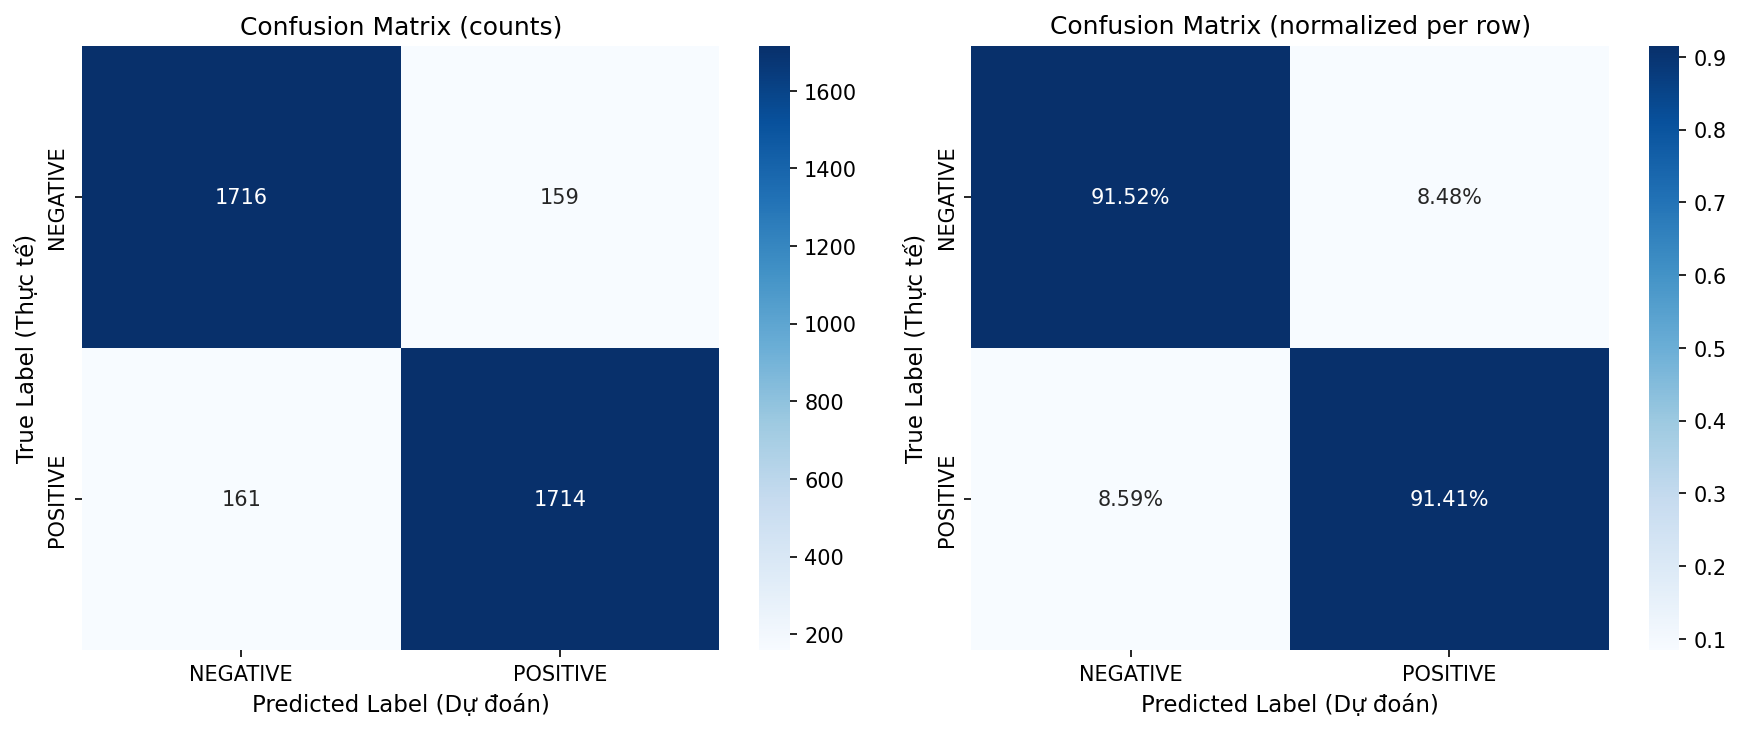


Giải thích CM:
  Hàng = True label (nhãn thực tế)
  Cột  = Predicted label (nhãn model dự đoán)
  Đường chéo = Dự đoán đúng
  Ngoài chéo = Dự đoán sai


In [16]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Raw counts
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=axes[0])
axes[0].set_xlabel('Predicted Label (Dự đoán)', fontsize=11)
axes[0].set_ylabel('True Label (Thực tế)', fontsize=11)
axes[0].set_title('Confusion Matrix (counts)', fontsize=12)

# Normalized
cm_norm = cm.astype(float) / cm.sum(axis=1)[:, np.newaxis]
sns.heatmap(cm_norm, annot=True, fmt='.2%', cmap='Blues',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=axes[1])
axes[1].set_xlabel('Predicted Label (Dự đoán)', fontsize=11)
axes[1].set_ylabel('True Label (Thực tế)', fontsize=11)
axes[1].set_title('Confusion Matrix (normalized per row)', fontsize=12)

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/plots/confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nGiải thích CM:')
print('  Hàng = True label (nhãn thực tế)')
print('  Cột  = Predicted label (nhãn model dự đoán)')
print('  Đường chéo = Dự đoán đúng')
print('  Ngoài chéo = Dự đoán sai')

## 13. Metrics: Precision, Recall, F1

In [17]:
report = classification_report(y_true, y_pred, target_names=CLASS_NAMES, digits=4)
print(report)

# Giải thích từng class
print('Giải thích:')
tn, fp, fn, tp = cm.ravel()
prec_pos = tp / (tp + fp)
rec_pos  = tp / (tp + fn)
print(f'  POSITIVE - Precision = TP/(TP+FP) = {tp}/({tp}+{fp}) = {prec_pos:.4f}')
print(f'              "Trong số những lần model đoán POSITIVE, {prec_pos*100:.1f}% thực sự đúng"')
print(f'  POSITIVE - Recall    = TP/(TP+FN) = {tp}/({tp}+{fn}) = {rec_pos:.4f}')
print(f'              "Trong tổng số POSITIVE thực tế, model tìm được {rec_pos*100:.1f}%"')

# Save full metrics
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
all_metrics = {
    'accuracy': float(accuracy_score(y_true, y_pred)),
    'precision_weighted': float(precision_score(y_true, y_pred, average='weighted')),
    'recall_weighted': float(recall_score(y_true, y_pred, average='weighted')),
    'f1_weighted': float(f1_score(y_true, y_pred, average='weighted')),
    'per_class': {
        'NEGATIVE': {
            'precision': float(precision_score(y_true, y_pred, pos_label=0)),
            'recall': float(recall_score(y_true, y_pred, pos_label=0)),
            'f1': float(f1_score(y_true, y_pred, pos_label=0))
        },
        'POSITIVE': {
            'precision': float(precision_score(y_true, y_pred, pos_label=1)),
            'recall': float(recall_score(y_true, y_pred, pos_label=1)),
            'f1': float(f1_score(y_true, y_pred, pos_label=1))
        }
    }
}
with open(f'{OUTPUT_DIR}/metrics/all_metrics.json', 'w') as f:
    json.dump(all_metrics, f, indent=2)
print('\nAll metrics saved.')

              precision    recall  f1-score   support

    NEGATIVE     0.9142    0.9152    0.9147      1875
    POSITIVE     0.9151    0.9141    0.9146      1875

    accuracy                         0.9147      3750
   macro avg     0.9147    0.9147    0.9147      3750
weighted avg     0.9147    0.9147    0.9147      3750

Giải thích:
  POSITIVE - Precision = TP/(TP+FP) = 1714/(1714+159) = 0.9151
              "Trong số những lần model đoán POSITIVE, 91.5% thực sự đúng"
  POSITIVE - Recall    = TP/(TP+FN) = 1714/(1714+161) = 0.9141
              "Trong tổng số POSITIVE thực tế, model tìm được 91.4%"

All metrics saved.


## 14. Error Analysis

In [18]:
# Find misclassified examples
test_texts = [test_ds[i]['text'] for i in range(len(test_ds))]
errors = [
    {
        'index': i,
        'text': test_texts[i],
        'true_label': int(y_true[i]),
        'pred_label': int(y_pred[i]),
        'confidence': float(y_probs[i].max()),
        'true_name': CLASS_NAMES[y_true[i]],
        'pred_name': CLASS_NAMES[y_pred[i]]
    }
    for i in range(len(y_true)) if y_true[i] != y_pred[i]
]

print(f'Total test samples: {len(y_true)}')
print(f'Correct:            {(y_true == y_pred).sum()} ({(y_true==y_pred).mean()*100:.2f}%)')
print(f'Errors:             {len(errors)} ({len(errors)/len(y_true)*100:.2f}%)')

# Error type breakdown
neg_as_pos = sum(1 for e in errors if e['true_label'] == 0)
pos_as_neg = sum(1 for e in errors if e['true_label'] == 1)
print(f'\nError breakdown:')
print(f'  NEGATIVE predicted as POSITIVE (FP): {neg_as_pos}')
print(f'  POSITIVE predicted as NEGATIVE (FN): {pos_as_neg}')

Total test samples: 3750
Correct:            3430 (91.47%)
Errors:             320 (8.53%)

Error breakdown:
  NEGATIVE predicted as POSITIVE (FP): 159
  POSITIVE predicted as NEGATIVE (FN): 161


In [19]:
# Show example errors
print('=== High-confidence errors (model sai nhưng rất tự tin) ===')
high_conf_errors = sorted(errors, key=lambda x: x['confidence'], reverse=True)[:5]
for i, err in enumerate(high_conf_errors, 1):
    print(f'\n{i}. Confidence: {err["confidence"]:.4f}')
    print(f'   True: {err["true_name"]} | Predicted: {err["pred_name"]}')
    print(f'   Text: {err["text"][:200]}...')

=== High-confidence errors (model sai nhưng rất tự tin) ===

1. Confidence: 0.9953
   True: POSITIVE | Predicted: NEGATIVE
   Text: The movie actually has a fairly good story, but gets bogged down in several key places. It's almost as if the director threw the movie together without taking the time to make some essential cuts in t...

2. Confidence: 0.9937
   True: NEGATIVE | Predicted: POSITIVE
   Text: America. A land of freedom, of hope and of dreams. This is the nation that, since its independence, has striven to bring democracy, prosperity, and peace to the entire world, for the good of all manki...

3. Confidence: 0.9927
   True: NEGATIVE | Predicted: POSITIVE
   Text: What this movie does well is combine action and horror with comedy and drama in a unique way that teases more emotion form the audience than a typical horror movie. Unfortunately with disjointed story...

4. Confidence: 0.9917
   True: NEGATIVE | Predicted: POSITIVE
   Text: Medellin is a fabulous place to live, wo

Text length - Correct predictions:  mean=231.2, median=171.0
Text length - Incorrect predictions: mean=254.8, median=194.0


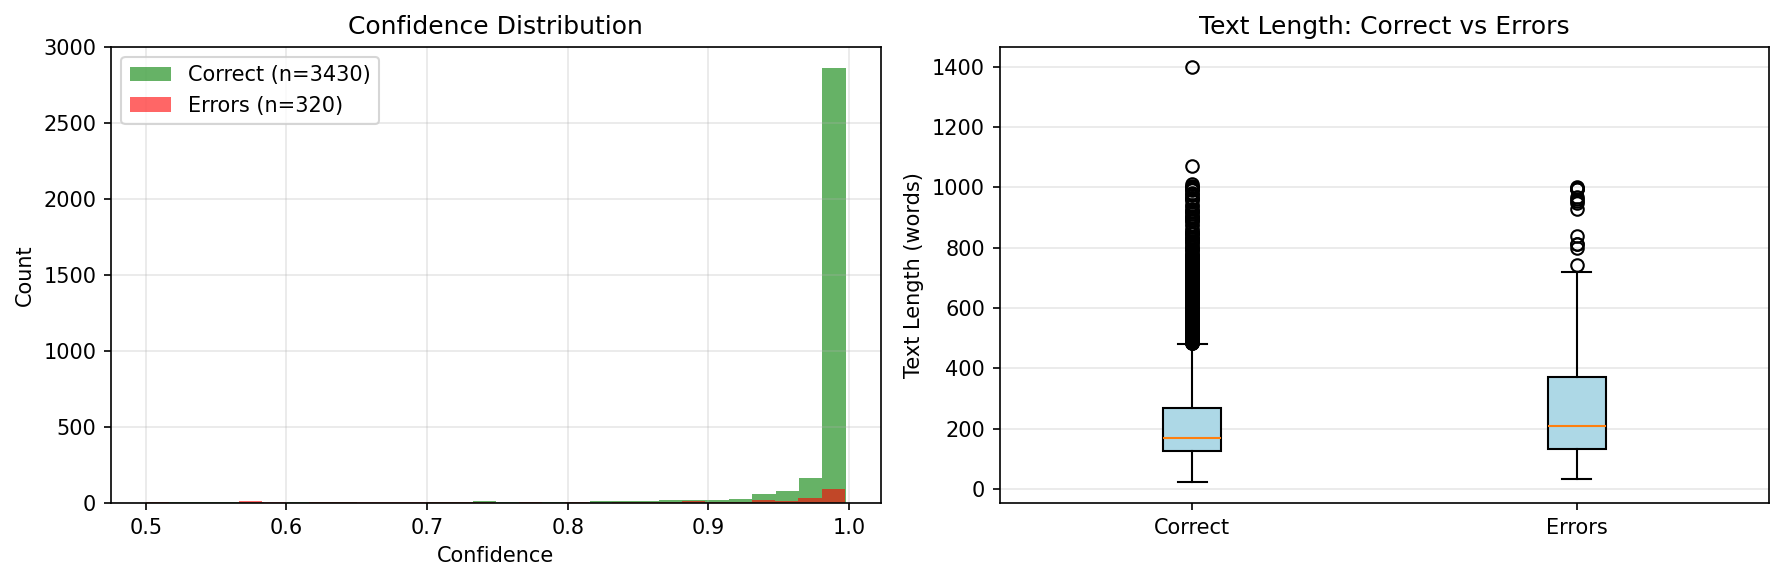

Error analysis saved.


In [20]:
# Text length analysis: correct vs incorrect
correct_lengths = [len(test_texts[i].split()) for i in range(len(y_true)) if y_true[i] == y_pred[i]]
error_lengths   = [e['text'].split().__len__() for e in errors]

print(f'Text length - Correct predictions:  mean={np.mean(correct_lengths):.1f}, median={np.median(correct_lengths):.1f}')
print(f'Text length - Incorrect predictions: mean={np.mean(error_lengths):.1f}, median={np.median(error_lengths):.1f}')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Confidence distribution
correct_conf = y_probs.max(axis=1)[y_true == y_pred]
error_conf   = y_probs.max(axis=1)[y_true != y_pred]
axes[0].hist(correct_conf, bins=30, alpha=0.6, label=f'Correct (n={len(correct_conf)})', color='green')
axes[0].hist(error_conf, bins=30, alpha=0.6, label=f'Errors (n={len(error_conf)})', color='red')
axes[0].set_xlabel('Confidence')
axes[0].set_ylabel('Count')
axes[0].set_title('Confidence Distribution')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Text length comparison
axes[1].boxplot([correct_lengths, error_lengths], labels=['Correct', 'Errors'], patch_artist=True,
                boxprops=dict(facecolor='lightblue'))
axes[1].set_ylabel('Text Length (words)')
axes[1].set_title('Text Length: Correct vs Errors')
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/plots/error_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

# Save error analysis
with open(f'{OUTPUT_DIR}/metrics/error_analysis.json', 'w') as f:
    json.dump({'total_errors': len(errors), 'fp': neg_as_pos, 'fn': pos_as_neg,
               'sample_errors': errors[:20]}, f, indent=2)
print('Error analysis saved.')

## 15.    Résumé Final

In [21]:
print('=' * 60)
print('EXERCISE 2 SUMMARY')
print('=' * 60)
print(f'Model:      {MODEL_NAME}')
print(f'Dataset:    IMDb ({len(train_idx)} train / {len(val_idx)} val / {len(test_idx)} test)')
print(f'Epochs:     3')
print(f'Batch size: 32')
print(f'LR:         2e-5')
print()
print(f'Test Accuracy:  {all_metrics["accuracy"]:.4f} ({all_metrics["accuracy"]*100:.2f}%)')
print(f'Test F1:        {all_metrics["f1_weighted"]:.4f}')
print(f'Total errors:   {len(errors)} / {len(y_true)}')
print()
print('Artifacts saved:')
print(f'  outputs/exercise2/metrics/training_history.csv')
print(f'  outputs/exercise2/metrics/confusion_matrix.npy')
print(f'  outputs/exercise2/metrics/all_metrics.json')
print(f'  outputs/exercise2/metrics/error_analysis.json')
print(f'  outputs/exercise2/plots/training_curves.png')
print(f'  outputs/exercise2/plots/confusion_matrix.png')
print(f'  outputs/exercise2/model/best_model/')
print('=' * 60)

EXERCISE 2 SUMMARY
Model:      distilbert-base-uncased
Dataset:    IMDb (17500 train / 3750 val / 3750 test)
Epochs:     3
Batch size: 32
LR:         2e-5

Test Accuracy:  0.9147 (91.47%)
Test F1:        0.9147
Total errors:   320 / 3750

Artifacts saved:
  outputs/exercise2/metrics/training_history.csv
  outputs/exercise2/metrics/confusion_matrix.npy
  outputs/exercise2/metrics/all_metrics.json
  outputs/exercise2/metrics/error_analysis.json
  outputs/exercise2/plots/training_curves.png
  outputs/exercise2/plots/confusion_matrix.png
  outputs/exercise2/model/best_model/
